*2026 Spring DSAA 2011 Machine Learning*
## Lab Note 12
*Yiyun CHEN, Shuyu SHEN, Zixin ZHONG*
*Hong Kong University of Science and Technology (Guangzhou)*

### Q1: t-Distributed Stochastic Neighbor Embedding (t-SNE) Algorithm Details

1. **High-dimensional similarities**:
   $$p_{j|i} = \frac{\exp(-\|x_i-x_j\|^2/2\sigma_i^2)}{\sum_{k\ne i}\exp(-\|x_i-x_k\|^2/2\sigma_i^2)}$$
   t-SNE chooses $\sigma_i$ so that each point has approximately the requested **perplexity**, i.e., an effective neighborhood size.
2. **Low-dimensional similarities**:
   $$q_{ij} = \frac{(1 + \|y_i-y_j\|^2)^{-1}}{\sum_{k\ne l}(1 + \|y_k-y_l\|^2)^{-1}}$$
   The heavy-tailed Student-t kernel helps reduce the crowding problem.
3. **Objective**:
   $$C = KL(P\|Q) = \sum_i \sum_j p_{ij}\log\frac{p_{ij}}{q_{ij}}$$
   The optimization is asymmetric: it penalizes close neighbors in high dimension that are placed too far apart in 2D.

**Task: Explore t-SNE parameters on the Iris dataset**

- Standardize the four Iris features before running t-SNE.
- Try the grid `perplexities = [5, 30, 50]` and `learning_rates = [10, 200, 500]`.
- Keep `random_state=42` so the plots are reproducible.
- Compare how perplexity and learning rate affect cluster separation and global layout.

In [1]:
# Q1 setup: load libraries and prepare the Iris data.
# ----------------------------------------------------
# numpy: numeric arrays and summary statistics
# matplotlib: plotting the low-dimensional embedding
# load_iris: a small built-in dataset, so the example runs without external files
# TSNE: the nonlinear dimensionality-reduction algorithm we want to study
# StandardScaler: makes each feature comparable before distance-based modeling
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Load the classic Iris dataset.
# X contains 150 flowers x 4 features:
# sepal length, sepal width, petal length, and petal width.
# y contains the species ID. We do NOT give y to t-SNE; y is only used to color the plot.
iris = load_iris()
X = iris.data
y = iris.target

print(f"Feature names: {iris.feature_names}")
print(f"Target names:  {iris.target_names.tolist()}")
print(f"Data shape: {X.shape}; labels shape: {y.shape}")
print(f"First 5 feature rows:\n{X[:5]}")
print(f"First 5 labels: {y[:5]}")

# Why standardize?
# t-SNE starts from pairwise distances. If one feature has a much larger scale,
# it can dominate those distances even when it is not conceptually more important.
# StandardScaler transforms each feature to mean 0 and standard deviation 1.
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(f"Standardized feature means: {X_std.mean(axis=0).round(3)}")
print(f"Standardized feature stds:  {X_std.std(axis=0).round(3)}")
print("Analysis: the transformed means are approximately 0 and stds are approximately 1, so all four features contribute comparably to t-SNE distances.")

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names:  ['setosa', 'versicolor', 'virginica']
Data shape: (150, 4); labels shape: (150,)
First 5 feature rows:
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
First 5 labels: [0 0 0 0 0]
Standardized feature means: [-0. -0. -0. -0.]
Standardized feature stds:  [1. 1. 1. 1.]
Analysis: the transformed means are approximately 0 and stds are approximately 1, so all four features contribute comparably to t-SNE distances.


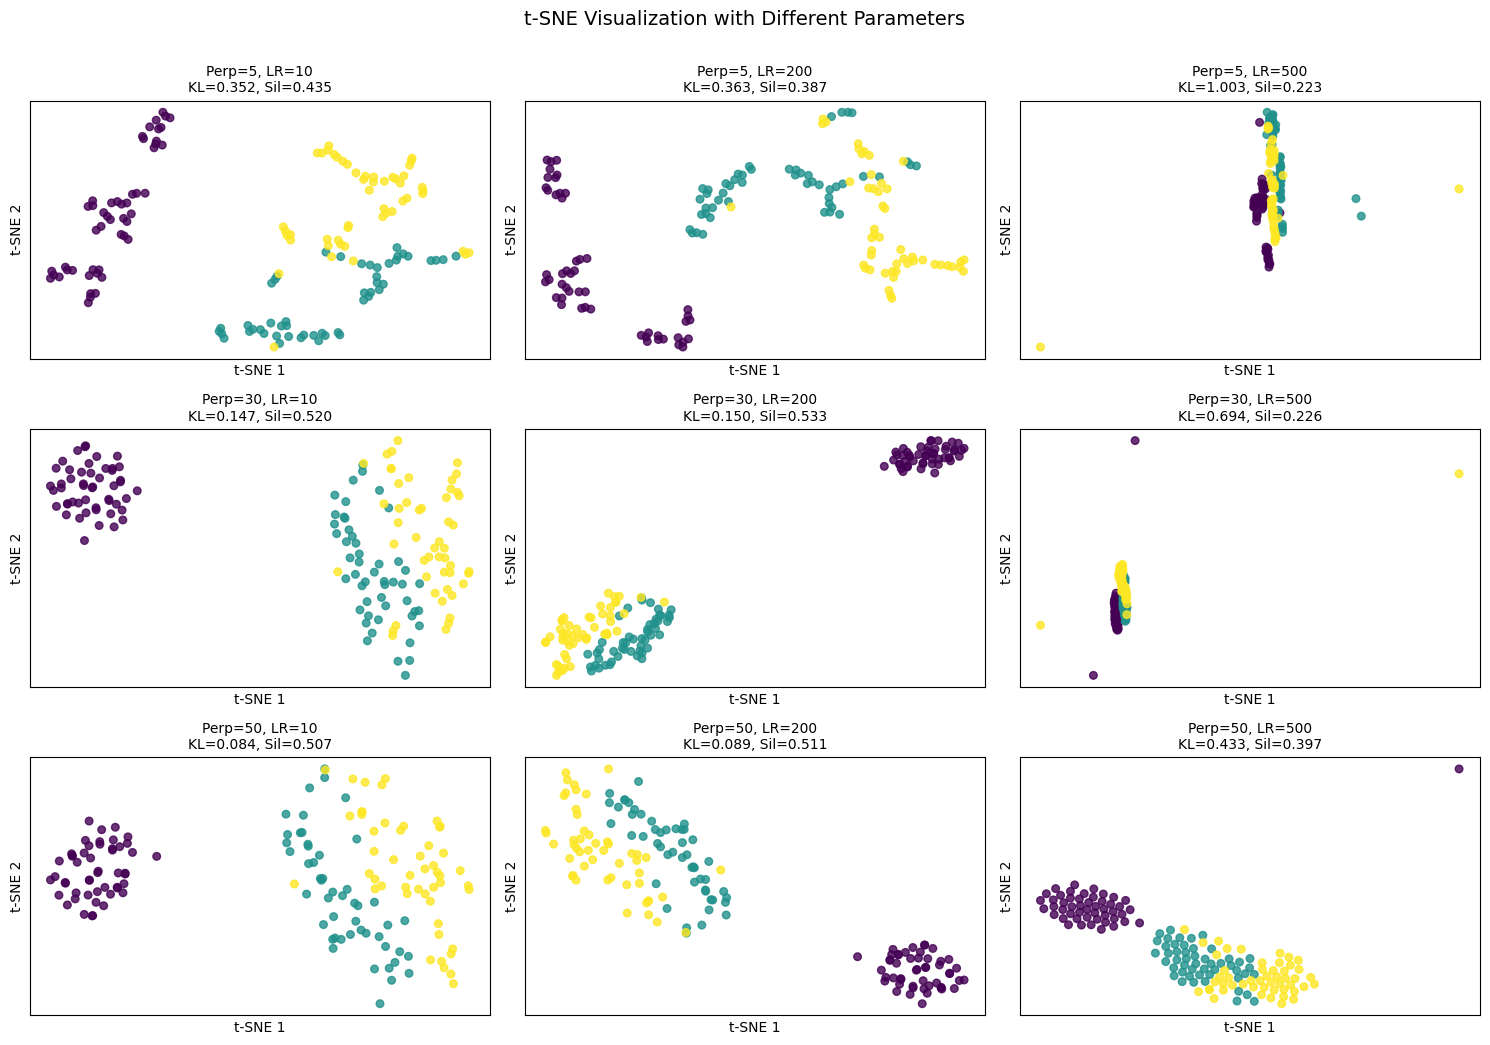

Parameter grid summary:
  perplexity=5 , learning_rate=10  -> KL=0.3523, Silhouette=0.4354
  perplexity=5 , learning_rate=200 -> KL=0.3627, Silhouette=0.3869
  perplexity=5 , learning_rate=500 -> KL=1.0034, Silhouette=0.2235
  perplexity=30, learning_rate=10  -> KL=0.1468, Silhouette=0.5204
  perplexity=30, learning_rate=200 -> KL=0.1504, Silhouette=0.5330
  perplexity=30, learning_rate=500 -> KL=0.6945, Silhouette=0.2264
  perplexity=50, learning_rate=10  -> KL=0.0844, Silhouette=0.5073
  perplexity=50, learning_rate=200 -> KL=0.0889, Silhouette=0.5110
  perplexity=50, learning_rate=500 -> KL=0.4328, Silhouette=0.3966

Detailed analysis:
- Lowest KL divergence: perplexity=50, learning_rate=10, KL=0.0844.
- Best label separation by Silhouette: perplexity=30, learning_rate=200, Silhouette=0.5330.
- KL and Silhouette answer different questions: KL measures t-SNE objective fit; Silhouette measures class separation using labels.
- In Iris, setosa usually separates cleanly, while versicolor

In [2]:
# Q1: run t-SNE over a small parameter grid.
# -----------------------------------------
# Perplexity roughly corresponds to the number of effective neighbors considered by t-SNE.
# - Small perplexity: emphasizes very local structure.
# - Large perplexity: considers broader neighborhoods and can smooth the layout.
# Learning rate controls the optimization step size.
# - Too small: optimization may move slowly or compress points.
# - Too large: optimization may overshoot and produce unstable layouts.
from sklearn.metrics import silhouette_score

perplexities = [5, 30, 50]
learning_rates = [10, 200, 500]

# We record two quantitative summaries for each embedding:
# 1. KL divergence: t-SNE's own objective; lower is better for matching high-dimensional similarities.
# 2. Silhouette score: uses true Iris labels to evaluate visible class separation in 2D.
#    This is not part of t-SNE training, but it helps us interpret the plot.
records = []

plt.figure(figsize=(15, 10))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        # init='pca' gives a stable starting point and usually reduces random-looking rotations.
        # random_state=42 ensures the same result every time this notebook is run.
        tsne = TSNE(
            n_components=2,
            perplexity=perp,
            learning_rate=lr,
            init='pca',
            random_state=42
        )
        X_tsne = tsne.fit_transform(X_std)
        sil = silhouette_score(X_tsne, y)
        records.append({
            'perplexity': perp,
            'learning_rate': lr,
            'kl': tsne.kl_divergence_,
            'silhouette': sil
        })

        ax = plt.subplot(3, 3, i * 3 + j + 1)
        plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', s=30, alpha=0.8)
        plt.title(f"Perp={perp}, LR={lr}\nKL={tsne.kl_divergence_:.3f}, Sil={sil:.3f}", fontsize=10)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.suptitle('t-SNE Visualization with Different Parameters', y=1.04, fontsize=14)
plt.show()

print("Parameter grid summary:")
for r in records:
    print(
        f"  perplexity={r['perplexity']:<2}, learning_rate={r['learning_rate']:<3} "
        f"-> KL={r['kl']:.4f}, Silhouette={r['silhouette']:.4f}"
    )

best_by_kl = min(records, key=lambda r: r['kl'])
best_by_sil = max(records, key=lambda r: r['silhouette'])
print("\nDetailed analysis:")
print(f"- Lowest KL divergence: perplexity={best_by_kl['perplexity']}, learning_rate={best_by_kl['learning_rate']}, KL={best_by_kl['kl']:.4f}.")
print(f"- Best label separation by Silhouette: perplexity={best_by_sil['perplexity']}, learning_rate={best_by_sil['learning_rate']}, Silhouette={best_by_sil['silhouette']:.4f}.")
print("- KL and Silhouette answer different questions: KL measures t-SNE objective fit; Silhouette measures class separation using labels.")
print("- In Iris, setosa usually separates cleanly, while versicolor and virginica often stay closer because they overlap in the original feature space.")
print("- A visually nice t-SNE plot should be treated as exploratory evidence, not as proof that the original data has exactly those global distances.")

### Q2: Comparative Analysis of Linear vs. Non-linear Dimensionality Reduction (PCA vs. t-SNE)

**Task Description:**
Use the Handwritten Digits Dataset (**Digits Dataset**, 64-dimensional) from `sklearn.datasets`.

1. Apply **PCA** and **t-SNE** to reduce the data dimensionality to 2D.
2. For t-SNE, experiment with two `perplexity` values, such as 5 and 30.
3. Visualize all 2D embeddings with digit labels as colors.
4. Use the **Silhouette Score** to quantify cluster separation in the 2D space.
5. Use **Trustworthiness@10** to measure how well local neighborhoods from the original 64D space are preserved.
6. Explain why t-SNE often gives visually cleaner local clusters than PCA, and why global distances in t-SNE should still be interpreted carefully.

Original Data Shape: (1797, 64)
Number of classes: 10; class labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


PCA explained variance ratio: [0.1203 0.0956]


PCA total explained variance in 2D: 0.2159
PCA Silhouette Score: 0.0547
PCA Trustworthiness@10: 0.8163


t-SNE perplexity=5 Silhouette Score: 0.3922
t-SNE perplexity=5 Trustworthiness@10: 0.9820
t-SNE perplexity=5 final KL divergence: 0.9770


t-SNE perplexity=30 Silhouette Score: 0.4853
t-SNE perplexity=30 Trustworthiness@10: 0.9863
t-SNE perplexity=30 final KL divergence: 0.8369


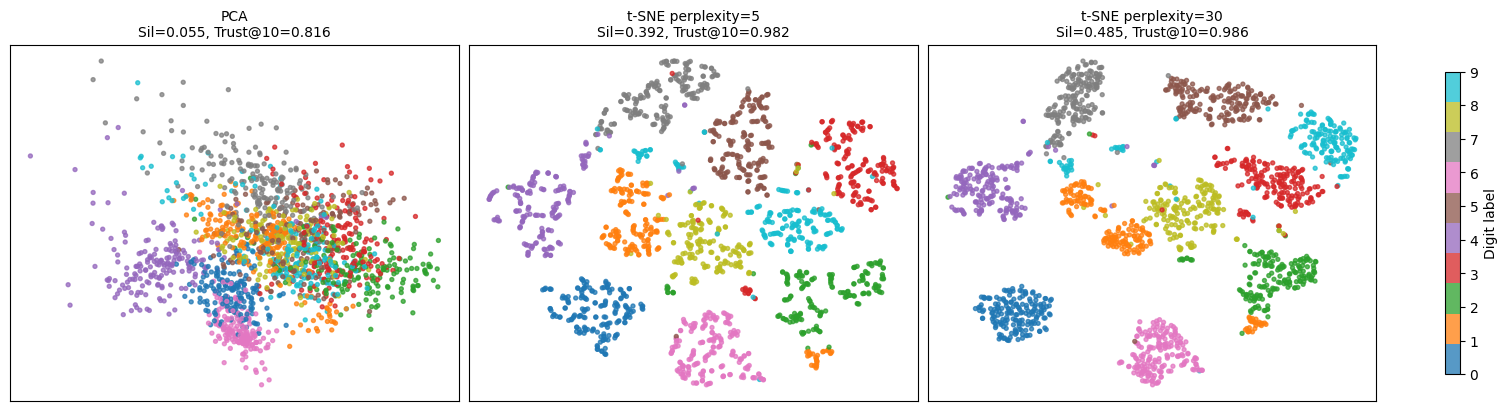


Detailed analysis:
- Best Silhouette Score: t-SNE perplexity=30 (0.4853), so it gives the clearest label separation in this 2D view.
- Best Trustworthiness@10: t-SNE perplexity=30 (0.9863), so it best preserves local neighborhoods from the 64D space.
- PCA explains only a limited fraction of variance in two dimensions, so several digit classes overlap in the PCA plot.
- t-SNE gives much higher trustworthiness, meaning that many local neighbor relationships survive the projection.
- The t-SNE plot is excellent for discovering local clusters, but distances between far-away clusters should not be read as precise original-space distances.


In [3]:
# Q2: compare PCA and t-SNE on handwritten digits.
# ------------------------------------------------
# Here the original data are 8x8 grayscale digit images flattened into 64 features.
# The central comparison:
# - PCA: linear, fast, preserves directions of maximum variance.
# - t-SNE: nonlinear, slower, tries to preserve local neighborhoods.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# 1. Load and preprocess data.
digits = load_digits()
X, y = digits.data, digits.target

# Standardization is useful because pixels/features can have different variance.
# This keeps high-variance pixels from dominating the distance calculations.
X_scaled = StandardScaler().fit_transform(X)

print(f"Original Data Shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}; class labels: {np.unique(y).tolist()}")

# 2. PCA baseline.
# PCA does not use labels. It simply finds the two linear directions with largest variance.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
score_pca = silhouette_score(X_pca, y)
trust_pca = trustworthiness(X_scaled, X_pca, n_neighbors=10)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_.round(4)}")
print(f"PCA total explained variance in 2D: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PCA Silhouette Score: {score_pca:.4f}")
print(f"PCA Trustworthiness@10: {trust_pca:.4f}")

# Metric notes:
# - Silhouette Score ranges from -1 to 1. Higher means labels form more separated clusters in 2D.
# - Trustworthiness ranges approximately from 0 to 1. Higher means 2D neighbors were also neighbors in 64D.
embeddings = {"PCA": X_pca}
metrics = {"PCA": {"silhouette": score_pca, "trust": trust_pca}}

# 3. t-SNE with two perplexities.
# The two perplexities let us compare a more local view (5) with a broader local-neighborhood view (30).
for perp in [5, 30]:
    tsne = TSNE(
        n_components=2,
        perplexity=perp,
        random_state=42,
        init='pca',
        learning_rate='auto'
    )
    X_tsne = tsne.fit_transform(X_scaled)
    name = f"t-SNE perplexity={perp}"
    embeddings[name] = X_tsne
    metrics[name] = {
        "silhouette": silhouette_score(X_tsne, y),
        "trust": trustworthiness(X_scaled, X_tsne, n_neighbors=10),
        "kl": tsne.kl_divergence_
    }
    print(f"{name} Silhouette Score: {metrics[name]['silhouette']:.4f}")
    print(f"{name} Trustworthiness@10: {metrics[name]['trust']:.4f}")
    print(f"{name} final KL divergence: {metrics[name]['kl']:.4f}")

# 4. Visual comparison.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, (name, embedding) in zip(axes, embeddings.items()):
    scatter = ax.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='tab10', s=8, alpha=0.75)
    ax.set_title(
        f"{name}\nSil={metrics[name]['silhouette']:.3f}, Trust@10={metrics[name]['trust']:.3f}",
        fontsize=10
    )
    ax.set_xticks([])
    ax.set_yticks([])

fig.colorbar(scatter, ax=axes, ticks=range(10), shrink=0.85, label='Digit label')
plt.show()

best_sil = max(metrics, key=lambda name: metrics[name]['silhouette'])
best_trust = max(metrics, key=lambda name: metrics[name]['trust'])
print("\nDetailed analysis:")
print(f"- Best Silhouette Score: {best_sil} ({metrics[best_sil]['silhouette']:.4f}), so it gives the clearest label separation in this 2D view.")
print(f"- Best Trustworthiness@10: {best_trust} ({metrics[best_trust]['trust']:.4f}), so it best preserves local neighborhoods from the 64D space.")
print("- PCA explains only a limited fraction of variance in two dimensions, so several digit classes overlap in the PCA plot.")
print("- t-SNE gives much higher trustworthiness, meaning that many local neighbor relationships survive the projection.")
print("- The t-SNE plot is excellent for discovering local clusters, but distances between far-away clusters should not be read as precise original-space distances.")

### Q3: Topic Modeling on News Corpora (LDA)

**Task Description:**
Use the `fetch_20newsgroups` dataset with four categories for speed:
`soc.religion.christian`, `comp.graphics`, `sci.med`, and `rec.autos`.

1. Remove headers, footers, and quoted replies to reduce metadata leakage.
2. Construct a Document-Term Matrix with `CountVectorizer`.
3. Train a **Latent Dirichlet Allocation (LDA)** model with 4 topics.
4. Print the top 5 keywords for each topic.
5. Infer the semantic meaning of each topic from its keywords.
6. Inspect how many documents are dominated by each learned topic, and show one representative snippet.

In [4]:
# Q3: topic modeling with LDA on four newsgroup categories.
# -------------------------------------------------------
# LDA is unsupervised: it sees only word counts, not the category labels.
# The labels are used after training only to help us evaluate whether the topics make sense.
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

# 1. Load a subset of the dataset.
# remove=('headers', 'footers', 'quotes') is important because email metadata can otherwise dominate the topics.
categories = ['soc.religion.christian', 'comp.graphics', 'sci.med', 'rec.autos']
dataset = fetch_20newsgroups(
    subset='train',
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)
print(f"Loaded {len(dataset.data)} documents.")
print(f"Original categories: {categories}")

# 2. Build the Document-Term Matrix.
# LDA is a count-based probabilistic model, so CountVectorizer is more appropriate than TF-IDF here.
# max_df removes words that are too common; min_df removes words too rare to define stable topics.
# token_pattern keeps alphabetic tokens with at least two characters, reducing numeric noise.
custom_stop_words = list(ENGLISH_STOP_WORDS.union({
    'edu', 'com', 'article', 'writes', 'nntp', 'posting', 'host',
    'university', 'organization', 'subject', 'lines', 'know', 'like',
    'just', 'don', 'does', 'did', 'use', 'people', 'think', 'good',
    'time', 'way', 'make', 'new', 'said', 'right', 've', 'll',
    'really', 'say', 'things', 'years', 'thanks', 'want'
}))

tf_vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=5,
    stop_words=custom_stop_words,
    max_features=2000,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)
tf = tf_vectorizer.fit_transform(dataset.data)
feature_names = tf_vectorizer.get_feature_names_out()
print(f"Document-Term Matrix Shape: {tf.shape}")
print(f"Vocabulary examples: {feature_names[:10].tolist()}")

# 3. Train LDA.
# n_components=4 is chosen because we deliberately loaded four broad categories.
# In real unsupervised work, n_components is a modeling choice that should be tuned.
n_topics = 4
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=10,
    learning_method='batch',
    random_state=42
)
lda.fit(tf)

# doc_topic[d, k] is the estimated probability that document d belongs to topic k.
doc_topic = lda.transform(tf)
dominant_topics = doc_topic.argmax(axis=1)

# 4. Interpret topics using top words.
# LDA topics are distributions over words. The largest-weight words usually reveal the semantic theme.
label_keywords = {
    'religion / Christianity': {'god', 'jesus', 'church', 'christ', 'faith', 'bible', 'christians'},
    'automobiles': {'car', 'cars', 'engine', 'speed', 'dealer', 'auto', 'oil'},
    'medicine / health': {'health', 'medical', 'patients', 'disease', 'doctor', 'cancer', 'medicine'},
    'computer graphics': {'image', 'graphics', 'file', 'jpeg', 'software', 'data', 'program'}
}

def infer_topic_label(top_words):
    # This helper is only for readable classroom output.
    # It scores each hand-written label by overlap with the top LDA words.
    scores = {
        label: len(set(top_words) & keywords)
        for label, keywords in label_keywords.items()
    }
    best_label, best_score = max(scores.items(), key=lambda item: item[1])
    return best_label if best_score > 0 else 'inspect keywords manually'

topic_labels = {}

def display_topics(model, feature_names, no_top_words=5):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        label = infer_topic_label(top_words)
        topic_labels[topic_idx] = label
        print(f"Topic #{topic_idx}: {', '.join(top_words)}")
        print(f"  Inferred meaning: {label}")

print("\nExtracted Topic Keywords:")
display_topics(lda, feature_names, no_top_words=5)

# 5. Show topic sizes and representative documents.
# The most representative document has the largest probability for that topic.
print("\nDominant Topic Counts and Representative Documents:")
for topic_idx in range(n_topics):
    topic_count = int((dominant_topics == topic_idx).sum())
    best_doc_idx = int(np.argmax(doc_topic[:, topic_idx]))
    snippet = ' '.join(dataset.data[best_doc_idx].split())[:220]
    print(f"Topic #{topic_idx} ({topic_labels[topic_idx]}): {topic_count} documents")
    print(f"  Example: {snippet}...")

# 6. Compare learned topics with original category labels after training.
# This is a diagnostic only; the LDA model did not use these labels.
print("\nTopic vs. original category overlap:")
for topic_idx in range(n_topics):
    doc_indices = np.where(dominant_topics == topic_idx)[0]
    target_counts = np.bincount(dataset.target[doc_indices], minlength=len(categories))
    top_category_idx = int(target_counts.argmax())
    top_category = dataset.target_names[top_category_idx]
    purity = target_counts[top_category_idx] / max(1, target_counts.sum())
    print(f"Topic #{topic_idx} -> most common true category: {top_category} ({purity:.1%} of docs assigned to this topic)")

print("\nDetailed analysis:")
print("- The top words are semantically coherent, which means LDA recovered recognizable themes from word co-occurrence alone.")
print("- High overlap with the original categories is encouraging, but exact alignment is not guaranteed because LDA is unsupervised.")
print("- Representative snippets are useful sanity checks: they show whether the top-word interpretation matches actual text.")
print("- If metadata or generic words dominate, improve preprocessing before changing the topic model itself.")
print("- Some documents can naturally mix themes, so topic probabilities are more informative than a single hard assignment.")

Loaded 2371 documents.
Original categories: ['soc.religion.christian', 'comp.graphics', 'sci.med', 'rec.autos']
Document-Term Matrix Shape: (2371, 2000)
Vocabulary examples: ['ability', 'able', 'abs', 'absolute', 'absolutely', 'absolutes', 'ac', 'accept', 'acceptable', 'accepted']



Extracted Topic Keywords:
Topic #0: health, medical, patients, disease, food
  Inferred meaning: medicine / health
Topic #1: car, graphics, cars, mail, send
  Inferred meaning: automobiles
Topic #2: image, file, jpeg, files, images
  Inferred meaning: computer graphics
Topic #3: god, jesus, believe, church, christ
  Inferred meaning: religion / Christianity

Dominant Topic Counts and Representative Documents:
Topic #0 (medicine / health): 562 documents
  Example: ------------- cut here ----------------- HICNet Medical Newsletter Page 13 Volume 6, Number 10 April 20, 1993 Gonorrhea -- Colorado, 1985-1992 ================================ SOURCE: MMWR 42(14) DATE: Apr 16, 1993 The n...
Topic #1 (automobiles): 818 documents
  Example: Archive-Name: rec-autos/part2 Automotive Mailing Lists (Electronic Mail, that is): [last updated 3/17/93; new lotus, exotic cars list subscription info; added Portland, OR motorsports list, Corvair list, Triumph TR8 list...
Topic #2 (computer graphics): 267 

### Q4: Viterbi Decoding for Hidden Markov Models (HMM)

A core problem in HMMs is **decoding**: given an observation sequence $O$ and model parameters $\lambda$, find the most likely sequence of hidden states $S$.
This is typically solved with the **Viterbi Algorithm**, a dynamic programming method.

**Task Description:**
Since `sklearn` no longer provides HMM support, manually implement Viterbi decoding for a simple stock-market model.

- **Hidden States**: `[0: Bear Market, 1: Bull Market]`
- **Observations**: `[0: Down, 1: Up]`
- **Observation sequence**: `[Down, Down, Up, Down, Up]`
- **Output**: the most likely hidden-state path, its probability, and the dynamic-programming probability table.

In [5]:
# Q4: manual Viterbi decoding for a two-state HMM.
# -------------------------------------------------
# Goal: find the single most likely hidden-state sequence given observed outputs.
# This differs from choosing the best state at each day independently; Viterbi optimizes the whole path.
import numpy as np

# Hidden states describe market regime; observations describe daily price movement.
states = [0, 1]  # 0=Bear, 1=Bull
state_label = {0: 'Bear', 1: 'Bull'}
observations = [0, 0, 1, 0, 1]  # Down, Down, Up, Down, Up
obs_label = {0: 'Down', 1: 'Up'}

# Initial distribution: before seeing observations, Bear is slightly more likely.
start_prob = np.array([0.6, 0.4])

# Transition matrix A: A[i, j] = P(next_state=j | current_state=i).
# Diagonal entries are relatively high, so regimes tend to persist.
trans_prob = np.array([
    [0.7, 0.3],
    [0.4, 0.6]
])

# Emission matrix B: B[state, observation] = P(observation | state).
# Bear tends to emit Down; Bull tends to emit Up.
emission_prob = np.array([
    [0.8, 0.2],
    [0.3, 0.7]
])

def viterbi(obs, states, start_p, trans_p, emit_p):
    # V[t][s] stores the probability of the best path that ends at state s at time t.
    V = [{}]
    # path[s] stores the actual best state sequence ending at state s.
    path = {}

    # 1. Initialization:
    # best probability of starting in state y and generating the first observation.
    for y in states:
        V[0][y] = start_p[y] * emit_p[y][obs[0]]
        path[y] = [y]

    # 2. Recursion:
    # For each current state y, test every previous state y0 and keep the best predecessor.
    for t in range(1, len(obs)):
        V.append({})
        newpath = {}
        for y in states:
            candidates = [
                (V[t - 1][y0] * trans_p[y0][y] * emit_p[y][obs[t]], y0)
                for y0 in states
            ]
            prob, state = max(candidates, key=lambda item: item[0])
            V[t][y] = prob
            newpath[y] = path[state] + [y]
        path = newpath

    # 3. Termination:
    # Choose the best final state; its path is the globally best hidden-state sequence.
    final_candidates = [(V[len(obs) - 1][y], y) for y in states]
    prob, state = max(final_candidates, key=lambda item: item[0])
    return prob, path[state], V

prob, state_sequence, V = viterbi(observations, states, start_prob, trans_prob, emission_prob)
state_names = [state_label[s] for s in state_sequence]
obs_names = [obs_label[o] for o in observations]

# Convert the dynamic-programming table to a matrix for easier display.
viterbi_table = np.array([[V[t][s] for s in states] for t in range(len(observations))])
print("Viterbi probability table; columns are [Bear, Bull]:")
print(np.round(viterbi_table, 6))
print(f"Observation Sequence: {obs_names}")
print(f"Most Likely Hidden State Sequence: {state_names}")
print(f"Probability of this path: {prob:.6f}")

print("\nDay-by-day decoded path:")
for day, (obs_name, state_name) in enumerate(zip(obs_names, state_names), start=1):
    print(f"  Day {day}: observation={obs_name:<4} -> decoded state={state_name}")

print("\nDetailed analysis:")
print("- Day 1 starts as Bear because P(Bear) * P(Down | Bear) = 0.6 * 0.8 = 0.48, larger than the Bull alternative.")
print("- The first two Down observations strongly reinforce the Bear path.")
print("- On Day 3, an Up observation supports Bull locally, but switching too early must also pay the transition probability cost.")
print("- The final Up is strong enough that the best complete path ends in Bull.")
print("- Do not decode by simply taking the larger number in each row of the Viterbi table; the backpointers recover the best complete path.")
print("- Viterbi is dynamic programming: it keeps only the best prefix for each possible current state, avoiding enumeration of all 2^5 paths.")

Viterbi probability table; columns are [Bear, Bull]:
[[0.48     0.12    ]
 [0.2688   0.0432  ]
 [0.037632 0.056448]
 [0.021074 0.010161]
 [0.00295  0.004426]]
Observation Sequence: ['Down', 'Down', 'Up', 'Down', 'Up']
Most Likely Hidden State Sequence: ['Bear', 'Bear', 'Bear', 'Bear', 'Bull']
Probability of this path: 0.004426

Day-by-day decoded path:
  Day 1: observation=Down -> decoded state=Bear
  Day 2: observation=Down -> decoded state=Bear
  Day 3: observation=Up   -> decoded state=Bear
  Day 4: observation=Down -> decoded state=Bear
  Day 5: observation=Up   -> decoded state=Bull

Detailed analysis:
- Day 1 starts as Bear because P(Bear) * P(Down | Bear) = 0.6 * 0.8 = 0.48, larger than the Bull alternative.
- The first two Down observations strongly reinforce the Bear path.
- On Day 3, an Up observation supports Bull locally, but switching too early must also pay the transition probability cost.
- The final Up is strong enough that the best complete path ends in Bull.
- Do not 

### Q5: Gaussian Graphical Models and Structure Learning

In a Gaussian Markov Random Field, zeros in the **precision matrix** $\Theta = \Sigma^{-1}$ correspond to conditional independence between two variables given all others.
Thus, non-zero off-diagonal precision entries represent edges in an **undirected** graph.

**Task Description:**
Use the California Housing dataset.

1. Select a small subset of features for readability.
2. Standardize features before covariance estimation.
3. Use Graphical Lasso to estimate a sparse inverse covariance matrix.
   In code, import `GraphicalLasso` from `sklearn.covariance`.
4. Print the precision matrix and list the graph edges.
5. For each edge, report the **partial correlation**:

$$
\rho_{ij\mid \mathrm{rest}}
= -\frac{\Theta_{ij}}{\sqrt{\Theta_{ii}\Theta_{jj}}}.
$$

6. Visualize the partial-correlation matrix and the learned graph structure.

Feature order: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population']
Precision matrix:
[[ 1.491  0.068 -0.849  0.037 -0.   ]
 [ 0.068  1.078 -0.    -0.     0.281]
 [-0.849 -0.     1.485 -0.    -0.   ]
 [ 0.037 -0.    -0.     1.001 -0.   ]
 [-0.     0.281 -0.    -0.     1.074]]

Partial correlation matrix:
[[ 1.    -0.053  0.57  -0.03   0.   ]
 [-0.053  1.     0.     0.    -0.261]
 [ 0.57   0.     1.     0.     0.   ]
 [-0.03   0.     0.     1.     0.   ]
 [ 0.    -0.261  0.     0.     1.   ]]

Learned Graph Structure (|precision entry| > 0.01 implies a plotted edge):
Feature A       -- Feature B       : Partial Corr
-------------------------------------------------------
MedInc          -- HouseAge        : -0.0534
MedInc          -- AveRooms        :  0.5705
MedInc          -- AveBedrms       : -0.0304
HouseAge        -- Population      : -0.2611

Number of learned edges: 4
Strongest conditional relationship: MedInc -- AveRooms with partial correlation 0.5705


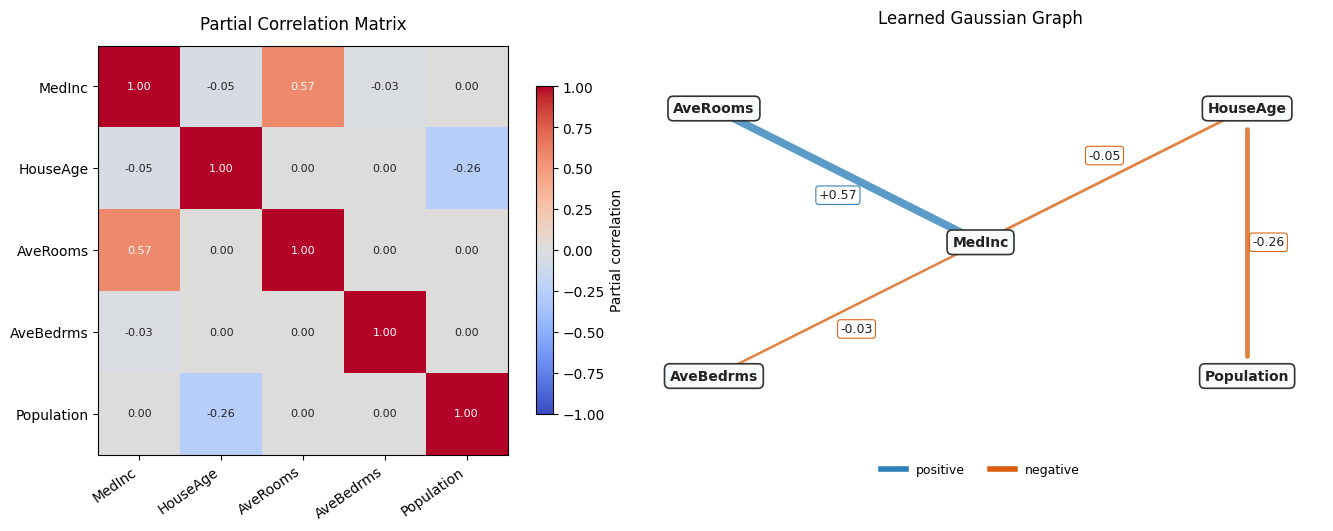


Detailed analysis:
- A plotted edge here means the off-diagonal precision entry is above the chosen threshold, suggesting conditional dependence after controlling for the other selected features.
- Positive partial correlation means the two variables tend to move together after conditioning on the rest.
- Negative partial correlation means they move in opposite directions after conditioning on the rest.
- MedInc and AveRooms have the strongest positive conditional relationship in this subset.
- HouseAge and Population show a negative conditional relationship after accounting for income and room-related features.
- The graph is sparse because Graphical Lasso penalizes weak conditional dependencies toward zero, which makes the structure easier to interpret.


In [6]:
# Q5: Gaussian Graphical Model / Markov Random Field structure learning.
# ---------------------------------------------------------------------
# Key idea:
# - Covariance measures marginal relationships.
# - Precision matrix (inverse covariance) reveals conditional relationships.
# - A zero off-diagonal precision entry suggests conditional independence given all other variables.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.covariance import GraphicalLasso
from sklearn.preprocessing import StandardScaler

# 1. Load data.
# We use only five features so the learned graph is readable on one slide/screen.
data = fetch_california_housing()
X = data.data[:1000, :5]  # first 1000 samples and first 5 features
feature_names = data.feature_names[:5]
print(f"Feature order: {feature_names}")

# 2. Standardize data.
# Covariance and precision estimates are scale-sensitive; standardization makes coefficients comparable.
X_std = StandardScaler().fit_transform(X)

# 3. Learn sparse inverse covariance.
# Graphical Lasso estimates the precision matrix while applying L1 regularization.
# L1 regularization shrinks weak off-diagonal entries exactly to zero, producing a sparse graph.
# alpha controls sparsity: larger alpha usually means fewer edges.
model = GraphicalLasso(alpha=0.2)
model.fit(X_std)

precision_matrix = model.precision_

# 4. Convert precision entries to partial correlations.
# Precision entries are not normalized, so their magnitudes depend on diagonal values.
# Partial correlation normalizes them to a [-1, 1] scale:
# rho_ij|rest = -Theta_ij / sqrt(Theta_ii * Theta_jj).
n_features = len(feature_names)
partial_corr_matrix = np.zeros_like(precision_matrix)
for i in range(n_features):
    for j in range(n_features):
        if i == j:
            partial_corr_matrix[i, j] = 1.0
        else:
            partial_corr_matrix[i, j] = -precision_matrix[i, j] / np.sqrt(
                precision_matrix[i, i] * precision_matrix[j, j]
            )

# 5. Print matrices and edge list.
print("Precision matrix:")
print(np.round(precision_matrix, 3))

print("\nPartial correlation matrix:")
print(np.round(partial_corr_matrix, 3))

edge_threshold = 1e-2
print(f"\nLearned Graph Structure (|precision entry| > {edge_threshold:g} implies a plotted edge):")
print(f"{'Feature A':<15} -- {'Feature B':<15} : {'Partial Corr'}")
print("-" * 55)

edges = []
for i in range(n_features):
    for j in range(i + 1, n_features):
        theta_ij = precision_matrix[i, j]
        if abs(theta_ij) > edge_threshold:
            partial_corr = partial_corr_matrix[i, j]
            edges.append((i, j, partial_corr))
            print(f"{feature_names[i]:<15} -- {feature_names[j]:<15} : {partial_corr: .4f}")

print(f"\nNumber of learned edges: {len(edges)}")

strongest_edge = max(edges, key=lambda edge: abs(edge[2]))
strong_i, strong_j, strong_weight = strongest_edge
print(
    "Strongest conditional relationship: "
    f"{feature_names[strong_i]} -- {feature_names[strong_j]} "
    f"with partial correlation {strong_weight:.4f}"
)

# 6. Visualize partial correlations and the learned graph.
# Left panel: matrix view, useful for exact pairwise values.
# Right panel: graph view, useful for explaining conditional dependency structure.
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5.2),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1.05, 1.25]}
)

im = axes[0].imshow(partial_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_title('Partial Correlation Matrix', pad=12)
axes[0].set_xticks(range(n_features), feature_names, rotation=35, ha='right')
axes[0].set_yticks(range(n_features), feature_names)
for i in range(n_features):
    for j in range(n_features):
        value = partial_corr_matrix[i, j]
        text_color = 'white' if abs(value) > 0.55 else '#222222'
        axes[0].text(j, i, f"{value:.2f}", ha='center', va='center', fontsize=8, color=text_color)
fig.colorbar(im, ax=axes[0], shrink=0.8, label='Partial correlation')

# A fixed layout avoids crossed edges and makes labels readable in class.
layout = {
    'MedInc': (0.0, 0.0),
    'AveRooms': (-1.75, 0.85),
    'AveBedrms': (-1.75, -0.85),
    'HouseAge': (1.75, 0.85),
    'Population': (1.75, -0.85),
}
positions = np.array([layout[name] for name in feature_names])
positive_color = '#2c7fb8'
negative_color = '#d95f0e'

axes[1].set_title('Learned Gaussian Graph', pad=16)

def draw_edge(ax, i, j, weight):
    start = positions[i]
    end = positions[j]
    delta = end - start
    length = np.linalg.norm(delta)
    unit = delta / length
    normal = np.array([-unit[1], unit[0]])

    # Trim the line slightly so it visually meets node boxes rather than running through text.
    trim = 0.13
    line_start = start + trim * unit
    line_end = end - trim * unit

    color = positive_color if weight > 0 else negative_color
    linewidth = 1.6 + 7.0 * abs(weight)
    ax.plot(
        [line_start[0], line_end[0]],
        [line_start[1], line_end[1]],
        color=color,
        linewidth=linewidth,
        alpha=0.78,
        solid_capstyle='round',
        zorder=1
    )

    # Edge label is offset from the line and drawn with a white background for readability.
    label_position = (start + end) / 2 + 0.14 * normal
    ax.text(
        label_position[0],
        label_position[1],
        f"{weight:+.2f}",
        ha='center',
        va='center',
        fontsize=9,
        color='#222222',
        bbox={
            'boxstyle': 'round,pad=0.22',
            'facecolor': 'white',
            'edgecolor': color,
            'linewidth': 0.8,
            'alpha': 0.96
        },
        zorder=4
    )

for i, j, weight in edges:
    draw_edge(axes[1], i, j, weight)

# Draw nodes last so they appear above edges.
for idx, name in enumerate(feature_names):
    x, y_pos = positions[idx]
    axes[1].text(
        x,
        y_pos,
        name,
        ha='center',
        va='center',
        fontsize=10,
        fontweight='semibold',
        color='#222222',
        bbox={
            'boxstyle': 'round,pad=0.38',
            'facecolor': '#f8fafc',
            'edgecolor': '#333333',
            'linewidth': 1.2
        },
        zorder=5
    )

axes[1].plot([], [], color=positive_color, linewidth=4, label='positive')
axes[1].plot([], [], color=negative_color, linewidth=4, label='negative')
axes[1].legend(loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False, fontsize=9)
axes[1].set_xlim(-2.25, 2.25)
axes[1].set_ylim(-1.35, 1.25)
axes[1].axis('off')
plt.show()

print("\nDetailed analysis:")
print("- A plotted edge here means the off-diagonal precision entry is above the chosen threshold, suggesting conditional dependence after controlling for the other selected features.")
print("- Positive partial correlation means the two variables tend to move together after conditioning on the rest.")
print("- Negative partial correlation means they move in opposite directions after conditioning on the rest.")
print("- MedInc and AveRooms have the strongest positive conditional relationship in this subset.")
print("- HouseAge and Population show a negative conditional relationship after accounting for income and room-related features.")
print("- The graph is sparse because Graphical Lasso penalizes weak conditional dependencies toward zero, which makes the structure easier to interpret.")